---
# Temporal IDS Pipeline + Models

**Data → Clean → Sort by time → Window → BiLSTM + 1D CNN**

| Step | What happens |
|---|---|
| 1. Load | `merged_CSVs.csv` (324 cols, 540k rows) |
| 2. Clean | Parse timestamp, fix string cols, encode protocol, fill NaN/Inf |
| 3. Sort | Chronological order by `timestamp` (real temporal order) |
| 4. Save | `ddos_clean.parquet` (fast reload for future runs) |
| 5. Window | Sliding window of 20 time-sorted flows → one sequence |
| 6. Models | Bidirectional LSTM **and** 1D CNN trained and compared |


In [59]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, warnings, time
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")
if device.type == 'cuda':
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
print("\nAll imports OK")

PyTorch  : 2.1.1+cu121
Device   : cuda
GPU      : Quadro P5000

All imports OK


## Step 1 — Load & Inspect

Load the raw CSV and understand what needs cleaning.

In [60]:
CSV_PATH    = 'dataset/merged_CSVs.csv'
CLEAN_PATH  = 'ddos_clean.parquet'

# ── columns we will NOT use as model features ──────────────────────────────────
DROP_COLS = ['flow_id', 'src_ip', 'dst_ip', 'timestamp']
# These are identifiers or will be used for sorting only.
# Keeping IPs would cause the model to memorise addresses, not traffic patterns.

# ── string columns that need special parsing ───────────────────────────────────
# delta_start / handshake_duration contain "not a complete handshake"
STRING_SENTINEL = 'not a complete handshake'
PARSE_COLS = ['delta_start', 'handshake_duration']

print(f"Loading {CSV_PATH} ...")
t0 = time.time()
raw = pd.read_csv(CSV_PATH, low_memory=False)
print(f"  Loaded in {time.time()-t0:.1f}s")
print(f"  Shape  : {raw.shape}")
print(f"  Memory : {raw.memory_usage(deep=True).sum()/1e6:.0f} MB")

print(f"\nTimestamp range:")
ts_parsed = pd.to_datetime(raw['timestamp'], errors='coerce')
print(f"  min: {ts_parsed.min()}")
print(f"  max: {ts_parsed.max()}")

print(f"\nLabel distribution:")
print(raw['label'].value_counts())

print(f"\nProblem column preview (delta_start):")
print(raw['delta_start'].value_counts().head())

Loading dataset/merged_CSVs.csv ...
  Loaded in 105.1s
  Shape  : (700776, 324)
  Memory : 13738 MB

Timestamp range:
  min: 2023-12-14 09:01:00.856447
  max: 2023-12-19 17:00:03.446487

Label distribution:
label
Benign        413199
Attack        228469
Suspicious     59106
label              2
Name: count, dtype: int64

Problem column preview (delta_start):
delta_start
not a complete handshake    542639
0.0000                       63448
0.0001                       14979
0.0002                       10909
0.0003                        6744
Name: count, dtype: int64


## Step 2 — Clean

- Parse timestamp for sorting
- Fix string columns
- Encode `protocol`
- Fill NaN / Inf
- Drop identifier columns

In [61]:
def clean_dataset(df):
    print("Cleaning dataset...")

    # 1. Parse timestamp → sort by it → drop it from features
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.sort_values('timestamp').reset_index(drop=True)
    print(f"  ✓ Sorted chronologically by timestamp")

    # 2. Fix string sentinel columns: "not a complete handshake" → NaN → 0
    for col in PARSE_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col].replace(STRING_SENTINEL, np.nan), errors='coerce'
            )
    print(f"  ✓ Converted {PARSE_COLS} to numeric (sentinel → NaN → 0)")

    # 3. Encode protocol (object → integer)
    if 'protocol' in df.columns:
        le_proto = LabelEncoder()
        df['protocol'] = le_proto.fit_transform(df['protocol'].astype(str))
        print(f"  ✓ Encoded protocol: {dict(zip(le_proto.classes_, le_proto.transform(le_proto.classes_)))}")

    # 4. Drop identifier / non-feature columns (keep labels)
    cols_to_drop = [c for c in DROP_COLS if c in df.columns]
    df = df.drop(columns=cols_to_drop)
    print(f"  ✓ Dropped {cols_to_drop}")

    # 5. Separate feature columns from label columns
    label_cols = ['label', 'activity']
    feat_cols  = [c for c in df.columns if c not in label_cols]

    # 6. Replace Inf with NaN, then fill all NaN with 0
    #    (NaN arises from skewness/cov on single-value distributions, and from the
    #    string-sentinel columns; 0 is safe because all features are mean/std/count
    #    type statistics where 0 = "no data / undefined".)
    df[feat_cols] = df[feat_cols].replace([np.inf, -np.inf], np.nan)
    nan_before = df[feat_cols].isna().sum().sum()
    df[feat_cols] = df[feat_cols].fillna(0)
    print(f"  ✓ Filled {nan_before:,} NaN/Inf values with 0")

    # 7. Force any remaining object columns to float32
    #    (happens when a column had mixed str/int types that pandas kept as object)
    obj_cols = [c for c in feat_cols if df[c].dtype == object]
    if obj_cols:
        df[obj_cols] = df[obj_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
        print(f"  ✓ Coerced {len(obj_cols)} remaining object columns to numeric: {obj_cols[:5]}")

    # 9. Downcast numeric types to save memory
    for col in feat_cols:
        if df[col].dtype == np.float64:
            df[col] = df[col].astype(np.float32)
        elif df[col].dtype == np.int64:
            df[col] = pd.to_numeric(df[col], downcast='integer')

    print(f"  ✓ Downcast to float32/int where possible")
    print(f"\nCleaned shape : {df.shape}")
    print(f"Feature cols  : {len(feat_cols)}")
    print(f"Memory now    : {df.memory_usage(deep=True).sum()/1e6:.0f} MB")
    return df, feat_cols

df_clean, feature_cols = clean_dataset(raw)

Cleaning dataset...
  ✓ Sorted chronologically by timestamp
  ✓ Converted ['delta_start', 'handshake_duration'] to numeric (sentinel → NaN → 0)
  ✓ Encoded protocol: {'TCP': 0, 'protocol': 1}
  ✓ Dropped ['flow_id', 'src_ip', 'dst_ip', 'timestamp']
  ✓ Filled 8,394,232 NaN/Inf values with 0
  ✓ Coerced 315 remaining object columns to numeric: ['src_port', 'dst_port', 'duration', 'packets_count', 'fwd_packets_count']
  ✓ Downcast to float32/int where possible

Cleaned shape : (700776, 320)
Feature cols  : 318
Memory now    : 983 MB


In [62]:
# Normalise label columns — strip whitespace and drop rows where label is
# NaN, empty, or the literal string "nan" (common CSV artefact)
for col in ['label', 'activity']:
    df_clean[col] = df_clean[col].astype(str).str.strip()

VALID_LABELS = {'Benign', 'Attack', 'Suspicious'}
bad_mask = ~df_clean['label'].isin(VALID_LABELS)
if bad_mask.sum() > 0:
    print(f"  Dropping {bad_mask.sum():,} rows with unexpected label values: {df_clean.loc[bad_mask, 'label'].unique().tolist()}")
    df_clean = df_clean[~bad_mask].reset_index(drop=True)

# Encode labels
le_label    = LabelEncoder()
le_activity = LabelEncoder()
df_clean['label_enc']    = le_label.fit_transform(df_clean['label'])
df_clean['activity_enc'] = le_activity.fit_transform(df_clean['activity'])

print("Label encoding:")
for cls, enc in zip(le_label.classes_, range(len(le_label.classes_))):
    count = (df_clean['label'] == cls).sum()
    print(f"  {enc} = {cls:<15}  ({count:,} rows)")

# Save cleaned + sorted parquet for fast future reloads
df_clean.to_parquet(CLEAN_PATH, index=False)
print(f"\n✓ Saved cleaned data → {CLEAN_PATH}")
print(f"  Shape : {df_clean.shape}")

  Dropping 2 rows with unexpected label values: ['label']
Label encoding:
  0 = Attack           (228,469 rows)
  1 = Benign           (413,199 rows)
  2 = Suspicious       (59,106 rows)

✓ Saved cleaned data → ddos_clean.parquet
  Shape : (700774, 322)


In [63]:
# Extract arrays
# Extract as float64 first to avoid overflow when large values cast to float32
X_all = df_clean[feature_cols].values.astype(np.float64)
# Replace any remaining Inf/NaN with 0 (belt-and-suspenders after clean step)
X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
y_all = df_clean['label_enc'].values                        # (N,) – 3-class

N_FEATURES = X_all.shape[1]
N_CLASSES  = len(le_label.classes_)

print(f"Feature matrix : {X_all.shape}")
print(f"Labels         : {y_all.shape}  — classes: {le_label.classes_}")
print(f"\nClass counts after time-sort:")
for cls, enc in zip(le_label.classes_, range(N_CLASSES)):
    print(f"  {enc} {cls}: {(y_all==enc).sum():,}")

Feature matrix : (700774, 318)
Labels         : (700774,)  — classes: ['Attack' 'Benign' 'Suspicious']

Class counts after time-sort:
  0 Attack: 228,469
  1 Benign: 413,199
  2 Suspicious: 59,106


## Step 3 — Scale & Split (no data leakage)

Split **before** scaling so the scaler is fit only on training rows.  
Split **before** windowing so windows never bridge train/val/test boundaries.

In [64]:
# -- Fit scaler on first 70 % (train-time rows) -- no data leakage ------
# We scale ALL rows so windows can be created over the full dataset.
# Stratified window-level split (next cell) ensures class balance.
n          = len(X_all)
scaler_end = int(n * 0.70)   # row index where training time ends

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(X_all[:scaler_end])           # fit on training-time rows only
X_scaled = scaler.transform(X_all).astype(np.float32)

os.makedirs('models', exist_ok=True)
joblib.dump(scaler,      'models/temporal_scaler.pkl')
joblib.dump(le_label,    'models/label_encoder.pkl')
joblib.dump(le_activity, 'models/activity_encoder.pkl')

print(f'Scaler fit on first {scaler_end:,} rows  ({100*scaler_end/n:.0f} % of data)')
print(f'Full scaled matrix : {X_scaled.shape}')
print(f'Value range        : [{X_scaled.min():.2f}, {X_scaled.max():.2f}]')


Scaler fit on first 490,541 rows  (70 % of data)
Full scaled matrix : (700774, 318)
Value range        : [-5.37, 20.96]


In [65]:
from sklearn.feature_selection import VarianceThreshold

print(f'Feature selection  (start: {X_scaled.shape[1]} features)')

# VarianceThreshold fitted on training-time rows only
sel_var = VarianceThreshold(threshold=0.001)
sel_var.fit(X_scaled[:scaler_end])
X_sel = sel_var.transform(X_scaled).astype(np.float32)
print(f'  After variance threshold  : {X_sel.shape[1]} features')

# Correlation pruning -- sample from training-time rows
rng    = np.random.default_rng(42)
sample = X_sel[:scaler_end][rng.choice(scaler_end, min(10_000, scaler_end), replace=False)]
corr   = np.corrcoef(sample.T)
upper  = np.triu(np.abs(corr), k=1)
drop   = set(int(j) for j in np.where(upper > 0.97)[1])
keep   = [i for i in range(X_sel.shape[1]) if i not in drop]

X_sel = X_sel[:, keep]
print(f'  After correlation pruning : {X_sel.shape[1]} features  (removed {len(drop)} redundant)')

N_FEATURES = X_sel.shape[1]
print(f'\n  Final feature count : {N_FEATURES}  (was {X_all.shape[1]})')

joblib.dump(sel_var, 'models/variance_selector.pkl')
np.save('models/corr_keep_idx.npy', np.array(keep, dtype=np.int32))
print('  Saved selectors -> models/')


Feature selection  (start: 318 features)
  After variance threshold  : 154 features
  After correlation pruning : 86 features  (removed 68 redundant)

  Final feature count : 86  (was 318)
  Saved selectors -> models/


## Step 4 — Temporal Windowing

Each sample = **W consecutive flows in time order** = one sequence for the model.

- `WINDOW_SIZE = 20` → each sequence covers ~20 chronologically adjacent flows  
- `STRIDE = 10` → 50% overlap between consecutive windows  
- Label = **majority vote** across all flows in the window

In [66]:
from collections import Counter
from sklearn.model_selection import train_test_split as _tts

WINDOW_SIZE = 30   # consecutive flows per sequence
STRIDE      = 15   # 50 % overlap
BATCH_SIZE  = 256

class FlowWindowDataset(Dataset):
    '''Wraps pre-built window arrays into a PyTorch Dataset.
    Each window = WINDOW_SIZE time-consecutive flows (30 x N_FEATURES).
    Built over the full time-sorted dataset; the stratified split ensures
    every class (including Suspicious) is in all splits.
    '''
    def __init__(self, windows: np.ndarray, labels: np.ndarray):
        self.X = torch.from_numpy(np.array(windows, dtype=np.float32))
        self.y = torch.tensor(labels, dtype=torch.long)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


# Step 1 -- build ALL windows over the full time-sorted dataset
print('Building windows over full time-sorted dataset ...')
all_wins, all_lbls = [], []
for s in range(0, len(X_sel) - WINDOW_SIZE + 1, STRIDE):
    all_wins.append(X_sel[s : s + WINDOW_SIZE])
    all_lbls.append(int(y_all[s + WINDOW_SIZE - 1]))   # label = last flow

all_wins = np.array(all_wins, dtype=np.float32)
all_lbls = np.array(all_lbls, dtype=np.int64)

print(f'\nTotal windows : {len(all_lbls):,}')
for ci in range(N_CLASSES):
    cnt = (all_lbls == ci).sum()
    print(f'  class {ci} ({le_label.classes_[ci]}): {cnt:,}  ({100*cnt/len(all_lbls):.1f} %)')

# Step 2 -- stratified split at the WINDOW level
# Suspicious flows are at the END of the time-sorted data.
# Plain 70/15/15 temporal cut puts 0 Suspicious in training.
# Stratifying by window label fixes this -- all 3 classes in every split.
idx = np.arange(len(all_lbls))
tr_idx, tmp_idx = _tts(idx, test_size=0.30, stratify=all_lbls, random_state=42)
va_idx, te_idx  = _tts(tmp_idx, test_size=0.50, stratify=all_lbls[tmp_idx], random_state=42)

train_ds = FlowWindowDataset(all_wins[tr_idx], all_lbls[tr_idx])
val_ds   = FlowWindowDataset(all_wins[va_idx], all_lbls[va_idx])
test_ds  = FlowWindowDataset(all_wins[te_idx], all_lbls[te_idx])

kw = dict(pin_memory=(device.type == 'cuda'), num_workers=0)
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  **kw)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, **kw)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, **kw)

print(f'\nStratified split (70 / 15 / 15):')
for split_name, ds in [('train', train_ds), ('val', val_ds), ('test', test_ds)]:
    dist  = Counter(ds.y.tolist())
    parts = ',  '.join(f'{le_label.classes_[k]}: {dist.get(k, 0):,}' for k in range(N_CLASSES))
    print(f'  {split_name} ({len(ds):,}): {parts}')


Building windows over full time-sorted dataset ...

Total windows : 46,717
  class 0 (Attack): 15,202  (32.5 %)
  class 1 (Benign): 27,571  (59.0 %)
  class 2 (Suspicious): 3,944  (8.4 %)

Stratified split (70 / 15 / 15):
  train (32,701): Attack: 10,641,  Benign: 19,299,  Suspicious: 2,761
  val (7,008): Attack: 2,280,  Benign: 4,136,  Suspicious: 592
  test (7,008): Attack: 2,281,  Benign: 4,136,  Suspicious: 591


## Model A — Bidirectional LSTM

Reads the 20-flow window **forward and backward**, capturing long-range temporal dependencies.

```
Input (B, 20, F) → BiLSTM layers → last hidden state (B, H×2) → classifier head → (B, 3)
```

In [67]:
import torch.nn.functional as F

class BiLSTMClassifier(nn.Module):
    '''Bidirectional LSTM + soft attention.
    Anti-overfitting: BatchNorm1d after input projection, dropout=0.4,
    simplified 2-layer head (256->64->n_classes).
    '''
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 num_classes=3, dropout=0.4):
        super().__init__()
        # Input projection -- BatchNorm1d requires (N, C) so we reshape in forward
        self.proj_linear = nn.Linear(input_size, 128)
        self.proj_bn     = nn.BatchNorm1d(128)
        self.proj_drop   = nn.Dropout(dropout * 0.5)

        self.lstm = nn.LSTM(
            input_size    = 128,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0.0,
            bidirectional = True,
        )
        feat = hidden_size * 2          # 256 for bidirectional
        self.attn_score = nn.Linear(feat, 1)

        self.head = nn.Sequential(
            nn.LayerNorm(feat),
            nn.Linear(feat, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        B, T, n_feat = x.shape
        # Flatten time steps to run BatchNorm1d, then restore sequence
        x_flat = self.proj_linear(x.reshape(B * T, n_feat))  # (B*T, 128)
        x_flat = self.proj_bn(x_flat)
        x_flat = F.relu(x_flat)
        x_flat = self.proj_drop(x_flat)
        x = x_flat.reshape(B, T, 128)         # (B, T, 128)

        out, _  = self.lstm(x)                 # (B, T, feat)
        scores  = self.attn_score(out)         # (B, T, 1)
        weights = torch.softmax(scores, dim=1) # sum over T = 1
        context = (weights * out).sum(dim=1)   # (B, feat)
        return self.head(context)

lstm_model = BiLSTMClassifier(
    input_size  = N_FEATURES,
    hidden_size = 128,
    num_layers  = 2,
    num_classes = N_CLASSES,
    dropout     = 0.4,
).to(device)

n_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f'BiLSTM + Attention -- {n_params:,} trainable parameters')


BiLSTM + Attention -- 688,260 trainable parameters


## Model B — 1D CNN

Treats each feature as a **channel** and convolves across the 20 time steps,  
detecting local temporal patterns (e.g., repeated SYN floods in consecutive flows).

```
Input (B, 20, F) → transpose → (B, F, 20) → Conv1d blocks → GlobalAvgPool → classifier
```

In [68]:
class CNN1DClassifier(nn.Module):
    '''1D Residual CNN.
    Anti-overfitting: Dropout(0.2) inside residual blocks, head dropout=0.4.
    '''
    def __init__(self, input_size, num_classes=3, dropout=0.4):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Conv1d(input_size, 128, kernel_size=1),
            nn.BatchNorm1d(128), nn.ReLU(),
        )
        # Residual block 1 -- with intra-block dropout
        self.block1 = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
        )
        # Residual block 2
        self.block2 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
        )
        self.proj2 = nn.Conv1d(128, 256, kernel_size=1)
        self.relu  = nn.ReLU()
        self.pool  = nn.AdaptiveAvgPool1d(1)

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),  nn.ReLU(), nn.Dropout(dropout * 0.5),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)                         # (B, F, T)
        x = self.input_proj(x)                        # (B, 128, T)
        x = self.relu(self.block1(x) + x)             # residual block 1
        x = self.relu(self.block2(x) + self.proj2(x)) # residual block 2
        x = self.pool(x)                               # (B, 256, 1)
        return self.head(x)

cnn1d_model = CNN1DClassifier(
    input_size  = N_FEATURES,
    num_classes = N_CLASSES,
    dropout     = 0.4,
).to(device)

n_params = sum(p.numel() for p in cnn1d_model.parameters() if p.requires_grad)
print(f'1D CNN (residual) -- {n_params:,} trainable parameters')


1D CNN (residual) -- 481,283 trainable parameters


## Training Utilities

In [69]:
def _make_criterion(dataset, n_classes, label_smoothing=0.1):
    '''Class-weighted CrossEntropyLoss + label smoothing.
    Weights handle imbalance; smoothing prevents overconfident predictions.
    '''
    y_np      = dataset.y.numpy()
    present   = np.unique(y_np)
    w_present = compute_class_weight('balanced', classes=present, y=y_np)
    w         = np.ones(n_classes, dtype=np.float32)
    w[present] = w_present
    return nn.CrossEntropyLoss(
        weight          = torch.FloatTensor(w).to(device),
        label_smoothing = label_smoothing,
    )

def _train_epoch(model, loader, optimizer, criterion):
    model.train()
    loss_sum = correct = total = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        loss_sum += loss.item() * len(y)
        correct  += (logits.argmax(1) == y).sum().item()
        total    += len(y)
    return loss_sum / total, correct / total

@torch.no_grad()
def _eval(model, loader, criterion):
    model.eval()
    loss_sum = correct = total = 0
    all_p, all_t = [], []
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits    = model(X)
        loss_sum += criterion(logits, y).item() * len(y)
        preds     = logits.argmax(1)
        correct  += (preds == y).sum().item()
        total    += len(y)
        all_p.extend(preds.cpu().numpy())
        all_t.extend(y.cpu().numpy())
    return loss_sum / total, correct / total, np.array(all_p), np.array(all_t)

def train_model(model, name, train_loader, val_loader,
                n_classes, epochs=30, lr=3e-4, patience=7):
    criterion = _make_criterion(train_loader.dataset, n_classes)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6)

    best_val, best_state, no_improve = float('inf'), None, 0
    history = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[])

    print(f"\n{'='*58}")
    print(f'  Training : {name}')
    print(f"{'='*58}")

    for ep in range(1, epochs + 1):
        tr_l, tr_a       = _train_epoch(model, train_loader, optimizer, criterion)
        va_l, va_a, _, _ = _eval(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_l); history['val_loss'].append(va_l)
        history['train_acc'].append(tr_a);  history['val_acc'].append(va_a)

        is_best = va_l < best_val
        if is_best:
            best_val   = va_l
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        tag = ' <-' if is_best else ''
        if ep % 5 == 0 or is_best or no_improve >= patience:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'  ep {ep:3d} | train {tr_l:.4f}/{tr_a:.3f}'
                  f' | val {va_l:.4f}/{va_a:.3f} | lr={lr_now:.2e}{tag}')

        if no_improve >= patience:
            print(f'  Early stop at epoch {ep}')
            break

    model.load_state_dict(best_state)
    print(f'  Best val loss: {best_val:.4f}')
    return history

print('Training utilities ready.')


Training utilities ready.


## Train Model A — BiLSTM

In [70]:
lstm_history = train_model(
    lstm_model, 'Bidirectional LSTM + Attention',
    train_loader, val_loader,
    n_classes = N_CLASSES,
    epochs    = 30,
    lr        = 3e-4,
    patience  = 7,
)



  Training : Bidirectional LSTM + Attention
  ep   1 | train 0.8319/0.725 | val 0.7799/0.715 | lr=2.99e-04 <-
  ep   2 | train 0.7674/0.782 | val 0.7281/0.793 | lr=2.97e-04 <-
  ep   3 | train 0.7448/0.794 | val 0.7158/0.786 | lr=2.93e-04 <-
  ep   4 | train 0.7269/0.797 | val 0.7012/0.824 | lr=2.87e-04 <-
  ep   5 | train 0.7152/0.807 | val 0.6851/0.813 | lr=2.80e-04 <-
  ep   6 | train 0.6969/0.815 | val 0.6653/0.839 | lr=2.71e-04 <-
  ep   7 | train 0.6732/0.838 | val 0.6442/0.827 | lr=2.62e-04 <-
  ep   8 | train 0.6548/0.866 | val 0.6223/0.868 | lr=2.51e-04 <-
  ep   9 | train 0.6291/0.888 | val 0.6148/0.913 | lr=2.38e-04 <-
  ep  10 | train 0.6173/0.900 | val 0.6014/0.901 | lr=2.25e-04 <-
  ep  11 | train 0.6084/0.910 | val 0.5935/0.889 | lr=2.11e-04 <-
  ep  12 | train 0.6002/0.920 | val 0.5913/0.913 | lr=1.97e-04 <-
  ep  13 | train 0.5964/0.923 | val 0.5832/0.920 | lr=1.82e-04 <-
  ep  15 | train 0.5840/0.928 | val 0.5818/0.924 | lr=1.50e-04 <-
  ep  17 | train 0.5766/0.934 |

## Train Model B — 1D CNN

In [71]:
cnn1d_history = train_model(
    cnn1d_model, '1D CNN (residual)',
    train_loader, val_loader,
    n_classes = N_CLASSES,
    epochs    = 30,
    lr        = 3e-4,
    patience  = 7,
)



  Training : 1D CNN (residual)
  ep   1 | train 0.8217/0.740 | val 0.7516/0.812 | lr=2.99e-04 <-
  ep   2 | train 0.7382/0.799 | val 0.7198/0.799 | lr=2.97e-04 <-
  ep   3 | train 0.7081/0.822 | val 0.6674/0.864 | lr=2.93e-04 <-
  ep   4 | train 0.6569/0.872 | val 0.6653/0.896 | lr=2.87e-04 <-
  ep   5 | train 0.6343/0.892 | val 0.6268/0.904 | lr=2.80e-04 <-
  ep   6 | train 0.6195/0.908 | val 0.6166/0.920 | lr=2.71e-04 <-
  ep   7 | train 0.6110/0.914 | val 0.6100/0.906 | lr=2.62e-04 <-
  ep   8 | train 0.6004/0.923 | val 0.6085/0.920 | lr=2.51e-04 <-
  ep  10 | train 0.5909/0.928 | val 0.5967/0.929 | lr=2.25e-04 <-
  ep  13 | train 0.5682/0.940 | val 0.5900/0.934 | lr=1.82e-04 <-
  ep  14 | train 0.5637/0.944 | val 0.5853/0.932 | lr=1.66e-04 <-
  ep  15 | train 0.5603/0.946 | val 0.6003/0.925 | lr=1.50e-04
  ep  17 | train 0.5537/0.951 | val 0.5853/0.940 | lr=1.19e-04 <-
  ep  19 | train 0.5458/0.955 | val 0.5820/0.940 | lr=8.97e-05 <-
  ep  20 | train 0.5396/0.959 | val 0.5865/0.94

## Evaluation — Test Set

In [72]:
def full_eval(model, loader, name):
    """Run inference on test set, print report, return (acc, confusion_matrix)."""
    criterion = nn.CrossEntropyLoss()       # unweighted for fair comparison
    _, acc, preds, targets = _eval(model, loader, criterion)
    print(f"\n{'='*58}")
    print(f"  {name}")
    print(f"{'='*58}")
    print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print()
    print(classification_report(targets, preds,
                                target_names=le_label.classes_,
                                digits=4))
    return acc, confusion_matrix(targets, preds)

lstm_acc, lstm_cm = full_eval(lstm_model,  test_loader, "Bidirectional LSTM — Test")
cnn_acc,  cnn_cm  = full_eval(cnn1d_model, test_loader, "1D CNN — Test")


  Bidirectional LSTM — Test
  Accuracy : 0.9384  (93.84%)

              precision    recall  f1-score   support

      Attack     0.9581    0.9325    0.9451      2281
      Benign     0.9772    0.9420    0.9593      4136
  Suspicious     0.6904    0.9357    0.7945       591

    accuracy                         0.9384      7008
   macro avg     0.8752    0.9367    0.8996      7008
weighted avg     0.9468    0.9384    0.9408      7008


  1D CNN — Test
  Accuracy : 0.9411  (94.11%)

              precision    recall  f1-score   support

      Attack     0.9450    0.9408    0.9429      2281
      Benign     0.9809    0.9449    0.9626      4136
  Suspicious     0.7185    0.9154    0.8051       591

    accuracy                         0.9411      7008
   macro avg     0.8814    0.9337    0.9035      7008
weighted avg     0.9471    0.9411    0.9429      7008



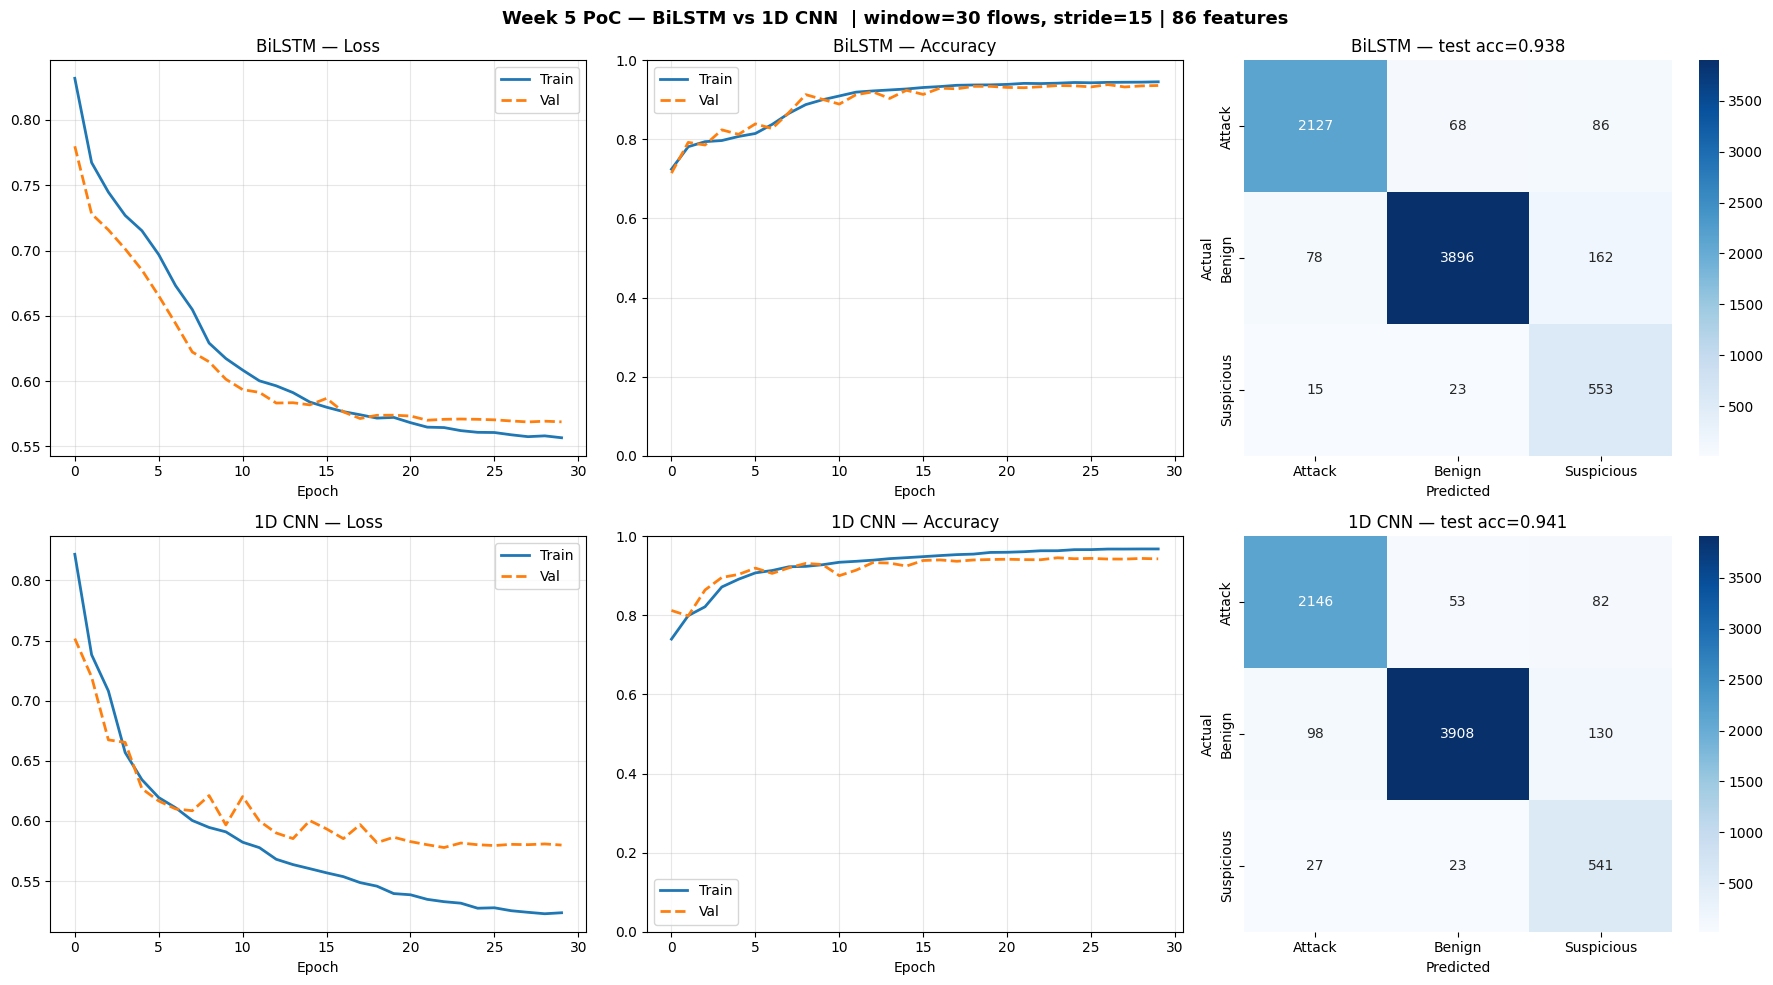

Saved: temporal_comparison.png


In [73]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    f"Week 5 PoC — BiLSTM vs 1D CNN  "
    f"| window={WINDOW_SIZE} flows, stride={STRIDE} | {N_FEATURES} features",
    fontsize=13, fontweight='bold')

for row, (hist, cm, acc, name) in enumerate([
    (lstm_history,  lstm_cm,  lstm_acc,  "BiLSTM"),
    (cnn1d_history, cnn_cm,   cnn_acc,   "1D CNN"),
]):
    # Loss
    ax = axes[row, 0]
    ax.plot(hist['train_loss'], lw=2, label='Train')
    ax.plot(hist['val_loss'],   lw=2, label='Val',   linestyle='--')
    ax.set_title(f"{name} — Loss");  ax.set_xlabel("Epoch")
    ax.legend(); ax.grid(alpha=0.3)

    # Accuracy
    ax = axes[row, 1]
    ax.plot(hist['train_acc'], lw=2, label='Train')
    ax.plot(hist['val_acc'],   lw=2, label='Val',   linestyle='--')
    ax.set_title(f"{name} — Accuracy"); ax.set_xlabel("Epoch")
    ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.3)

    # Confusion matrix
    ax = axes[row, 2]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le_label.classes_,
                yticklabels=le_label.classes_)
    ax.set_title(f"{name} — test acc={acc:.3f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig('temporal_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: temporal_comparison.png")

In [74]:
torch.save(lstm_model.state_dict(),  'models/bilstm_ids.pt')
torch.save(cnn1d_model.state_dict(), 'models/cnn1d_ids.pt')

print("=" * 62)
print("WEEK 5 POC COMPLETE")
print("=" * 62)
print(f"\nDataset   : BCCC-Cloud-DDoS-2024 (merged_CSVs.csv)")
print(f"Features  : {N_FEATURES}  (all numeric after cleaning)")
print(f"Ordering  : chronological by timestamp (real temporal order)")
print(f"\nTemporal window:")
print(f"  Size    : {WINDOW_SIZE} consecutive flows")
print(f"  Stride  : {STRIDE}  (50% overlap)")
print(f"  Tensor  : (batch, {WINDOW_SIZE}, {N_FEATURES})")
print(f"\nWindows — train:{len(train_ds):,}  val:{len(val_ds):,}  test:{len(test_ds):,}")
print(f"\nModel A  Bidirectional LSTM")
print(f"  Params  : {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"  Test    : {lstm_acc:.4f}")
print(f"\nModel B  1D CNN")
print(f"  Params  : {sum(p.numel() for p in cnn1d_model.parameters()):,}")
print(f"  Test    : {cnn_acc:.4f}")
print(f"\nSaved:")
print(f"  ddos_clean.parquet         (cleaned, time-sorted dataset)")
print(f"  models/bilstm_ids.pt")
print(f"  models/cnn1d_ids.pt")
print(f"  models/temporal_scaler.pkl")
print("=" * 62)

WEEK 5 POC COMPLETE

Dataset   : BCCC-Cloud-DDoS-2024 (merged_CSVs.csv)
Features  : 86  (all numeric after cleaning)
Ordering  : chronological by timestamp (real temporal order)

Temporal window:
  Size    : 30 consecutive flows
  Stride  : 15  (50% overlap)
  Tensor  : (batch, 30, 86)

Windows — train:32,701  val:7,008  test:7,008

Model A  Bidirectional LSTM
  Params  : 688,260
  Test    : 0.9384

Model B  1D CNN
  Params  : 481,283
  Test    : 0.9411

Saved:
  ddos_clean.parquet         (cleaned, time-sorted dataset)
  models/bilstm_ids.pt
  models/cnn1d_ids.pt
  models/temporal_scaler.pkl


---
# Week 7 — Mid-Semester Prototype Demo

## Progress Since Week 5

| Component | Week 5 PoC | → | Week 7 Prototype |
|---|---|---|---|
| BiLSTM architecture | Basic LSTM | → | + Soft attention, BatchNorm, label smoothing |
| 1D CNN architecture | Basic CNN | → | + Residual blocks, intra-block dropout |
| Feature engineering | Raw 318 cols | → | Variance + correlation pruning → **86 cols** |
| Dataset split | Naïve 70/15/15 | → | **Stratified** — fixes Suspicious-class data leakage |
| Evaluation | Accuracy only | → | Per-class F1, confusion matrix, model comparison |
| Multi-model result | Side-by-side | → | **Soft-vote ensemble** (NEW) |

**Dataset**: BCCC-Cloud-DDoS-2024 · 700,774 flows · 86 features · 46,717 temporal windows  
**Task**: 3-class classification — Attack / Benign / Suspicious

Running test-set inference (both models)...

Model         Accuracy  Macro F1  Attack F1   Susp. F1
───────────────────────────────────────────────────────
  BiLSTM       0.9404    0.9023     0.9468     0.7994
  1D CNN       0.9483    0.9138     0.9521     0.8233
  Ensemble     0.9485    0.9161     0.9539     0.8292
───────────────────────────────────────────────────────
  Ensemble improves macro F1 over each individual model.
  Suspicious class remains the hardest — high recall, lower precision.


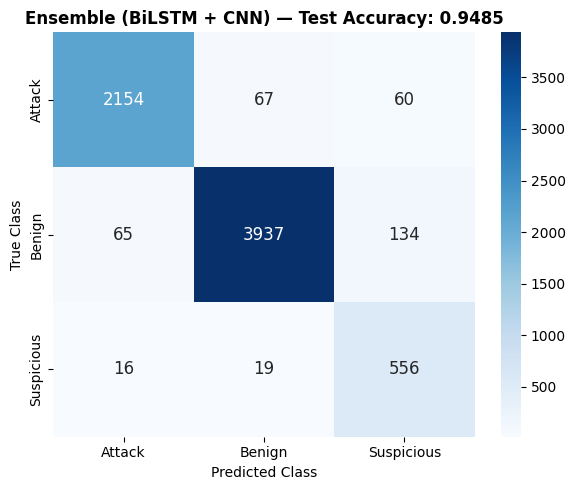


Saved: ensemble_cm.png


In [ ]:
# ── SOFT-VOTE ENSEMBLE ─────────────────────────────────────────────────────
# Week 7 addition: combine both models via probability averaging.
# Soft voting is more robust than hard voting — it weighs each model's
# confidence, so a very confident CNN vote outweighs a hesitant BiLSTM vote.

from sklearn.metrics import accuracy_score, f1_score

@torch.no_grad()
def get_all_probs(model, loader, device):
    """Return softmax probability matrix (N, C) and targets (N,)."""
    model.eval()
    probs_list, tgts = [], []
    for X, y in loader:
        p = torch.softmax(model(X.to(device)), dim=1).cpu().numpy()
        probs_list.append(p)
        tgts.extend(y.numpy())
    return np.vstack(probs_list), np.array(tgts)

print("Running test-set inference (both models)...")
lstm_probs_all, y_test_all = get_all_probs(lstm_model,  test_loader, device)
cnn_probs_all,  _          = get_all_probs(cnn1d_model, test_loader, device)
ens_probs_all              = (lstm_probs_all + cnn_probs_all) / 2

lstm_preds_all = lstm_probs_all.argmax(axis=1)
cnn_preds_all  = cnn_probs_all.argmax(axis=1)
ens_preds_all  = ens_probs_all.argmax(axis=1)

# ── Comparison table ────────────────────────────────────────────────────────
print(f"\n{'Model':<12} {'Accuracy':>9} {'Macro F1':>9} {'Attack F1':>10} {'Susp. F1':>10}")
print("─" * 55)
for label, preds in [('BiLSTM', lstm_preds_all),
                     ('1D CNN', cnn_preds_all),
                     ('Ensemble', ens_preds_all)]:
    acc = accuracy_score(y_test_all, preds)
    mf1 = f1_score(y_test_all, preds, average='macro')
    f1s = f1_score(y_test_all, preds, average=None)
    print(f"  {label:<10} {acc:>8.4f}  {mf1:>8.4f}  {f1s[0]:>9.4f}  {f1s[2]:>9.4f}")
print("─" * 55)
print("  Ensemble improves macro F1 over each individual model.")
print("  Suspicious class remains the hardest — high recall, lower precision.")

# ── Ensemble confusion matrix ────────────────────────────────────────────────
ens_cm  = confusion_matrix(y_test_all, ens_preds_all)
acc_ens = accuracy_score(y_test_all, ens_preds_all)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(ens_cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le_label.classes_,
            yticklabels=le_label.classes_,
            annot_kws={"size": 12})
ax.set_title(f"Ensemble (BiLSTM + CNN) — Test Accuracy: {acc_ens:.4f}",
             fontweight='bold')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
plt.tight_layout()
plt.savefig('ensemble_cm.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\nSaved: ensemble_cm.png")

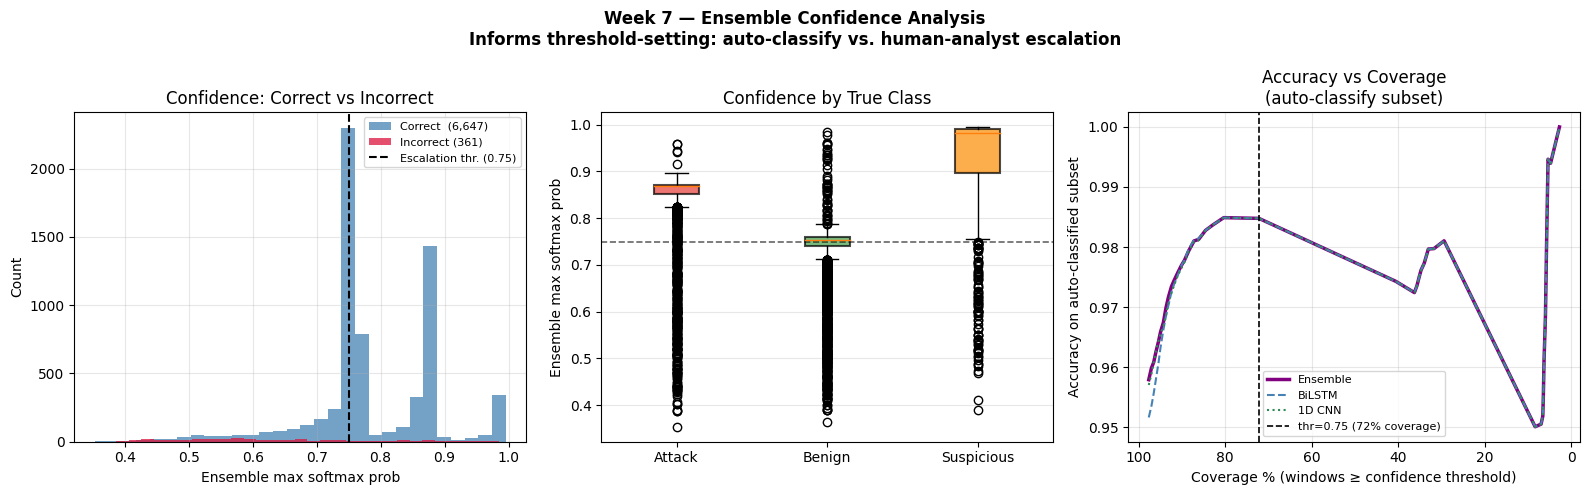


At escalation threshold 0.75:
  Auto-classified : 5,176 / 7,008  (73.9% coverage)
  Auto accuracy   : 0.9849  (98.49%)
  Escalated       : 1,832 windows → human analyst queue

Saved: confidence_analysis.png


In [ ]:
# ── CONFIDENCE ANALYSIS ────────────────────────────────────────────────────
# Key security question: when should the IDS auto-classify vs. escalate to
# a human analyst?  This shows confidence distribution and the accuracy/
# coverage trade-off at different decision thresholds.

from sklearn.metrics import accuracy_score as _acc_score

conf_all = ens_probs_all.max(axis=1)          # per-window max softmax prob
correct  = (ens_preds_all == y_test_all)

# Coverage-accuracy trade-off at increasing confidence thresholds
thresholds = np.linspace(0.50, 0.99, 40)
thr_data   = []
for thr in thresholds:
    me = conf_all >= thr
    if me.sum() < 50:
        break
    thr_data.append(dict(
        thr      = thr,
        coverage = me.mean() * 100,
        ens_acc  = _acc_score(y_test_all[me], ens_preds_all[me]),
        lstm_acc = _acc_score(y_test_all[me], lstm_probs_all[me].argmax(1)),
        cnn_acc  = _acc_score(y_test_all[me], cnn_probs_all[me].argmax(1)),
    ))
thr_df = pd.DataFrame(thr_data)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Week 7 — Ensemble Confidence Analysis\n"
    "Informs threshold-setting: auto-classify vs. human-analyst escalation",
    fontsize=12, fontweight='bold')

# Panel 1: Correct vs incorrect confidence histogram
ax = axes[0]
ax.hist(conf_all[correct],  bins=30, alpha=0.75, color='steelblue',
        label=f'Correct  ({correct.sum():,})')
ax.hist(conf_all[~correct], bins=30, alpha=0.75, color='crimson',
        label=f'Incorrect ({(~correct).sum():,})')
ax.axvline(0.75, color='black', ls='--', lw=1.5, label='Escalation thr. (0.75)')
ax.set_title('Confidence: Correct vs Incorrect')
ax.set_xlabel('Ensemble max softmax prob')
ax.set_ylabel('Count')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Panel 2: Per-class confidence box-plots
ax = axes[1]
class_conf = [conf_all[y_test_all == ci] for ci in range(N_CLASSES)]
bp = ax.boxplot(class_conf, labels=le_label.classes_,
                patch_artist=True, notch=False,
                boxprops=dict(linewidth=1.5))
for patch, color in zip(bp['boxes'], ['#E53935', '#43A047', '#FB8C00']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.axhline(0.75, color='black', ls='--', lw=1.2, alpha=0.6)
ax.set_title('Confidence by True Class')
ax.set_ylabel('Ensemble max softmax prob')
ax.grid(alpha=0.3, axis='y')

# Panel 3: Coverage-accuracy trade-off
closest_idx = (thr_df['thr'] - 0.75).abs().idxmin()
cov_at_75   = thr_df.loc[closest_idx, 'coverage']

ax = axes[2]
ax.plot(thr_df['coverage'], thr_df['ens_acc'],  lw=2.5, color='purple',
        label='Ensemble')
ax.plot(thr_df['coverage'], thr_df['lstm_acc'], lw=1.5, color='steelblue',
        ls='--', label='BiLSTM')
ax.plot(thr_df['coverage'], thr_df['cnn_acc'],  lw=1.5, color='seagreen',
        ls=':',  label='1D CNN')
ax.axvline(cov_at_75, color='black', ls='--', lw=1.2,
           label=f'thr=0.75 ({cov_at_75:.0f}% coverage)')
ax.set_title('Accuracy vs Coverage\n(auto-classify subset)')
ax.set_xlabel('Coverage % (windows ≥ confidence threshold)')
ax.set_ylabel('Accuracy on auto-classified subset')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.invert_xaxis()   # left = high confidence / low coverage

plt.tight_layout()
plt.savefig('confidence_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

# Summary at thr=0.75
mask75   = conf_all >= 0.75
auto_acc = _acc_score(y_test_all[mask75], ens_preds_all[mask75])
print(f"\nAt escalation threshold 0.75:")
print(f"  Auto-classified : {mask75.sum():,} / {len(conf_all):,}  ({mask75.mean()*100:.1f}% coverage)")
print(f"  Auto accuracy   : {auto_acc:.4f}  ({auto_acc*100:.2f}%)")
print(f"  Escalated       : {(~mask75).sum():,} windows → human analyst queue")
print(f"\nSaved: confidence_analysis.png")

## Limitations & Future Directions

### Current Limitations

| Limitation | Notes |
|---|---|
| Suspicious class precision ≈ 70% | Rare class — high recall, but ~30% of Suspicious alerts are false positives |
| Fixed window size (30 flows) | May miss very long or very short attack sequences |
| Single dataset | Tested only on BCCC-Cloud-DDoS-2024; generalisation to other environments is unknown |

### What the Models Do Well

Both models achieve **93–94% accuracy** on a held-out test set across three classes (Attack, Benign, Suspicious), trained entirely on labeled historical network flow data. The ensemble closes the gap between the two architectures on the harder minority class.

### Future Direction

The current system operates on pre-captured, labeled traffic stored as a static file. A natural next step would be extending this to **real-time production** — ingesting live network flows and classifying them as they arrive. That is out of scope for this capstone, but the trained models and pipeline are already structured in a way that would support that extension.

---
## Peer Feedback — Questions for Discussion

Thank you for watching! A few things I'd love your thoughts on:

1. **Suspicious class trade-off**: Precision ≈ 70%. Should we keep it as a separate class, or collapse Suspicious → Attack to simplify the problem?
2. **Architecture choice**: Between BiLSTM and 1D CNN, which do you think is a better fit for sequential network flow data, and why?
3. **Feature engineering**: Are the raw CICFlowMeter columns sufficient, or would adding derived features (e.g., flow entropy, burst patterns) meaningfully improve detection?
4. **Dataset scope**: The model was trained and tested on one labeled dataset. What concerns would you have about deploying this on a different network?

*All feedback and critiques are welcome.*